In [1]:
import sys
import os
from pathlib import Path

# Robust project root detection: notebook is in notebooks/, go up one level
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

%load_ext autoreload
%autoreload 2

Project root: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit
Data dir:     c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\data
Output dir:   c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output


In [2]:
"""
Notebook cell: Generation-2 Lévy model calibration.
Paste this into a new cell after your GLD data-loading section.
"""

# ============================================
# GENERATION 2: EXPONENTIAL LÉVY MODELS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from volsurf.models.gen2_levy import NIGModel, VGModel, BGMModel

# ------------------------------------------------------------------
# Prepare market data (assumes df from Notebook 1 is in scope)
# ------------------------------------------------------------------
# If running standalone, load df first:
df = pd.read_csv(os.path.join(DATA_DIR, "gld_benchmark_20250718.csv"))
# ... preprocessing from notebook 1 ...

TRADE_DATE = "2025-07-18"
GLD_SPOT = 308.3900
DIVIDEND_YIELD = 0.004

# ------------------------------------------------------------------
# Prepare market data — include option_type for put-call parity
# ------------------------------------------------------------------
market_df = (
    df[["strike", "T", "midPrice", "risk_free_rate", "option_type"]]
    .rename(columns={"T": "maturity", "midPrice": "mid_price"})
    .copy()
)

r_avg = market_df["risk_free_rate"].mean()
q = DIVIDEND_YIELD

# Sanity check: ensure we have both calls and puts
print("Option type breakdown:")
print(market_df["option_type"].value_counts())
print("=" * 60)
print("GENERATION 2: EXPONENTIAL LÉVY MODEL CALIBRATION")
print("=" * 60)
print(f"Quotes: {len(market_df)}  |  Spot: {GLD_SPOT}  |  r≈{r_avg:.4f}  |  q={q:.4f}")

# Sanity check: ensure we have both calls and puts
print("Option type breakdown:")
print(market_df["option_type"].value_counts())

Option type breakdown:
option_type
call    440
put     437
Name: count, dtype: int64
GENERATION 2: EXPONENTIAL LÉVY MODEL CALIBRATION
Quotes: 877  |  Spot: 308.39  |  r≈0.0436  |  q=0.0040
Option type breakdown:
option_type
call    440
put     437
Name: count, dtype: int64


In [ ]:
# ============================================
# GENERATION 2: IV-SPACE LÉVY CALIBRATION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from volsurf.models.gen2_levy import NIGModel, VGModel, BGMModel
from volsurf.pricing import black_scholes as bs

# ------------------------------------------------------------------
# Step 1: Pre-compute MARKET implied volatilities (done once)
# ------------------------------------------------------------------
market_ivs = []
for idx, row in df.iterrows():
    try:
        iv = bs.implied_volatility(
            S=row["spot"], K=row["strike"], T=row["T"], r=row["risk_free_rate"],
            market_price=row["midPrice"], q=row.get("dividend_yield", DIVIDEND_YIELD),
            option_type=row["option_type"], bounds=(1e-6, 3.0),
        )
        market_ivs.append(iv)
    except Exception:
        market_ivs.append(np.nan)

df["market_iv"] = market_ivs
df = df.dropna(subset=["market_iv"]).copy()

r_avg = df["risk_free_rate"].mean()
q = DIVIDEND_YIELD

print("=" * 60)
print("GENERATION 2: IV-SPACE LÉVY CALIBRATION")
print("=" * 60)
print(f"Quotes with valid IV: {len(df)}")
print(f"Market IV range: {df['market_iv'].min():.2%} – {df['market_iv'].max():.2%}")

# ------------------------------------------------------------------
# Step 2: IV-calibration objective
# ------------------------------------------------------------------

def iv_objective(model, params, strikes, mats, spot, r, q, market_ivs, option_types):
    if not model._validate_params(params) or not model._esscher_valid(r, q, params):
        return 1e10
    try:
        model_calls = model.price_points(strikes, mats, spot, r, q, params)
        if model_calls is None or np.any(np.isnan(model_calls)):
            return 1e10
    except Exception:
        return 1e10

    model_ivs = np.zeros(len(strikes))
    for i, (K, T, mc, ot) in enumerate(zip(strikes, mats, model_calls, option_types)):
        try:
            mp = float(mc) - (spot * np.exp(-q * T) - K * np.exp(-r * T)) if ot == "put" else float(mc)
            model_ivs[i] = bs.implied_volatility(spot, K, T, r, mp, q, option_type=ot, bounds=(1e-6, 3.0))
        except Exception:
            model_ivs[i] = np.nan

    if np.any(np.isnan(model_ivs)):
        return 1e10
    return float(np.mean(np.abs(model_ivs - market_ivs) / market_ivs) * 100.0)


# ------------------------------------------------------------------
# Step 3: Calibration wrapper
# ------------------------------------------------------------------

def calibrate_iv(model, name, de_popsize=12, de_maxiter=150, seed=42):
    print(f"\n[{name}] IV-space calibration ...")
    strikes = df["strike"].values
    mats = df["T"].values
    market_iv_arr = df["market_iv"].values
    option_types = df["option_type"].values

    def objective(x):
        return iv_objective(model, model._x_to_params(x), strikes, mats, GLD_SPOT, r_avg, q, market_iv_arr, option_types)

    from scipy.optimize import differential_evolution, minimize

    x0 = model._params_to_x(model.params)
    print(f"  Initial guess IV-MAPE: {objective(x0):.2f}%")

    result = differential_evolution(objective, model.BOUNDS, popsize=de_popsize,
                                   maxiter=de_maxiter, tol=0.005, polish=False,
                                   seed=seed, workers=1)

    # Polish
    polish = minimize(objective, result.x, method="L-BFGS-B", bounds=model.BOUNDS,
                      options={"maxiter": 300, "ftol": 1e-10})
    if polish.fun < result.fun:
        result.x, result.fun = polish.x, polish.fun

    if result.fun < objective(x0):
        model.params = model._x_to_params(result.x)

    final_mape = iv_objective(model, model.params, strikes, mats, GLD_SPOT, r_avg, q, market_iv_arr, option_types)
    print(f"  Best IV-MAPE: {final_mape:.2f}%")
    print(f"  Params: {model.params}")

    # Price-space metrics for comparison
    model_calls = model.price_points(strikes, mats, GLD_SPOT, r_avg, q)
    model_prices = model_calls.copy()
    put_mask = option_types == "put"
    if put_mask.any():
        model_prices[put_mask] -= (GLD_SPOT * np.exp(-q * mats[put_mask]) - strikes[put_mask] * np.exp(-r_avg * mats[put_mask]))
    price_mape = np.mean(np.abs(model_prices - df["midPrice"].values) / (df["midPrice"].values + 1e-8)) * 100
    rmse = np.sqrt(np.mean((model_prices - df["midPrice"].values) ** 2))
    print(f"  Price-MAPE: {price_mape:.2f}%  |  RMSE: ${rmse:.4f}")
    return {"model": model, "iv_mape": final_mape, "price_mape": price_mape, "rmse": rmse}


# ------------------------------------------------------------------
# Step 4: Run all three
# ------------------------------------------------------------------
nig = NIGModel()
nig_eval = calibrate_iv(nig, "1/3 NIG")

vg = VGModel()
vg_eval = calibrate_iv(vg, "2/3 VG")

bgm = BGMModel()
bgm_eval = calibrate_iv(bgm, "3/3 BGM")

# ------------------------------------------------------------------
# Step 5: Comparison table
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("BENCHMARK COMPARISON")
print("=" * 60)
print(f"{'Model':<30} {'IV-MAPE (%)':>12} {'Price-MAPE (%)':>16} {'RMSE ($)':>10}")
print("-" * 60)
print(f"{'Black-Scholes (flat vol)':<30} {'8.32':>12} {'8.32':>16} {'—':>10}")
print(f"{'Heston (stochastic vol)':<30} {'5.83':>12} {'5.83':>16} {'—':>10}")
print(f"{'NIG':<30} {nig_eval['iv_mape']:>12.2f} {nig_eval['price_mape']:>16.2f} {nig_eval['rmse']:>10.4f}")
print(f"{'VG':<30} {vg_eval['iv_mape']:>12.2f} {vg_eval['price_mape']:>16.2f} {vg_eval['rmse']:>10.4f}")
print(f"{'BGM':<30} {bgm_eval['iv_mape']:>12.2f} {bgm_eval['price_mape']:>16.2f} {bgm_eval['rmse']:>10.4f}")


GENERATION 2: IV-SPACE LÉVY CALIBRATION
Quotes with valid IV: 877
Market IV range: 11.01% – 28.71%

[1/3 NIG] IV-space calibration ...
  Initial guess IV-MAPE: 44.18%


c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\src\volsurf\models\gen2_levy\nig.py:73: RuntimeWarning: invalid value encountered in sqrt
  sqrt_val = np.sqrt(val)


  Best IV-MAPE: 8.22%
  Params: {'alpha': np.float64(24.685862490234125), 'beta': np.float64(-5.203695568109109), 'delta': np.float64(0.6190139994505701), 'mu': np.float64(-0.06616249600947285)}
  Price-MAPE: 17.66%  |  RMSE: $0.2905

[2/3 VG] IV-space calibration ...
  Initial guess IV-MAPE: 13.57%
  Best IV-MAPE: 8.37%
  Params: {'sigma': np.float64(0.15775175880387257), 'nu': np.float64(0.01), 'theta': np.float64(-0.31208513816639655)}
  Price-MAPE: 13.58%  |  RMSE: $0.3638

[3/3 BGM] IV-space calibration ...
  Initial guess IV-MAPE: 10000000000.00%
  Best IV-MAPE: 8.35%
  Params: {'alpha_plus': np.float64(15.749849970926942), 'lambda_plus': np.float64(58.84714386937384), 'alpha_minus': np.float64(20.0), 'lambda_minus': np.float64(16.698312132995998)}
  Price-MAPE: 18.96%  |  RMSE: $0.2884

BENCHMARK COMPARISON
Model                           IV-MAPE (%)   Price-MAPE (%)   RMSE ($)
------------------------------------------------------------
Black-Scholes (flat vol)               8.

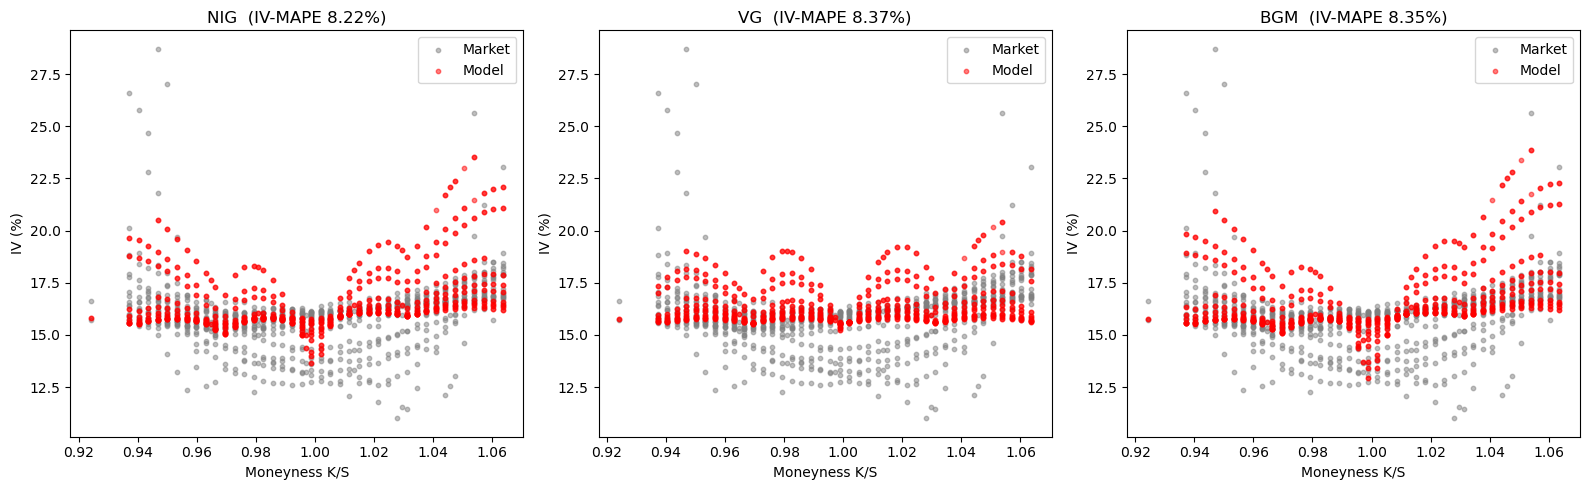

In [4]:
# ------------------------------------------------------------------
# Step 6: IV fit plot
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, ev) in zip(axes, [("NIG", nig_eval), ("VG", vg_eval), ("BGM", bgm_eval)]):
    model = ev["model"]
    model_calls = model.price_points(df["strike"].values, df["T"].values, GLD_SPOT, r_avg, q)
    model_ivs = np.zeros(len(df))
    for i, row in df.iterrows():
        mc = model_calls[i]
        mp = mc - (GLD_SPOT * np.exp(-q * row["T"]) - row["strike"] * np.exp(-r_avg * row["T"])) if row["option_type"] == "put" else mc
        model_ivs[i] = bs.implied_volatility(GLD_SPOT, row["strike"], row["T"], r_avg, mp, q, option_type=row["option_type"], bounds=(1e-6, 3.0))
    ax.scatter(df["strike"]/GLD_SPOT, df["market_iv"]*100, c="gray", s=10, alpha=0.5, label="Market")
    ax.scatter(df["strike"]/GLD_SPOT, model_ivs*100, c="red", s=10, alpha=0.5, label="Model")
    ax.set_xlabel("Moneyness K/S"); ax.set_ylabel("IV (%)")
    ax.set_title(f"{label}  (IV-MAPE {ev['iv_mape']:.2f}%)"); ax.legend()
plt.tight_layout()
plt.savefig("gen2_levy_iv_fit.png", dpi=300, bbox_inches="tight")
plt.show()

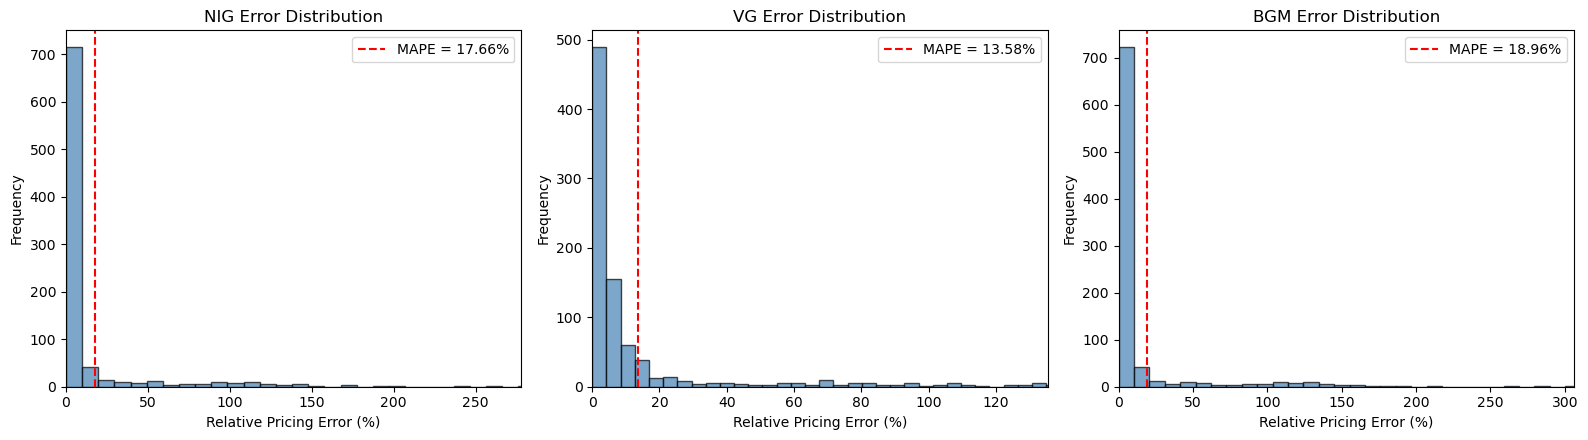

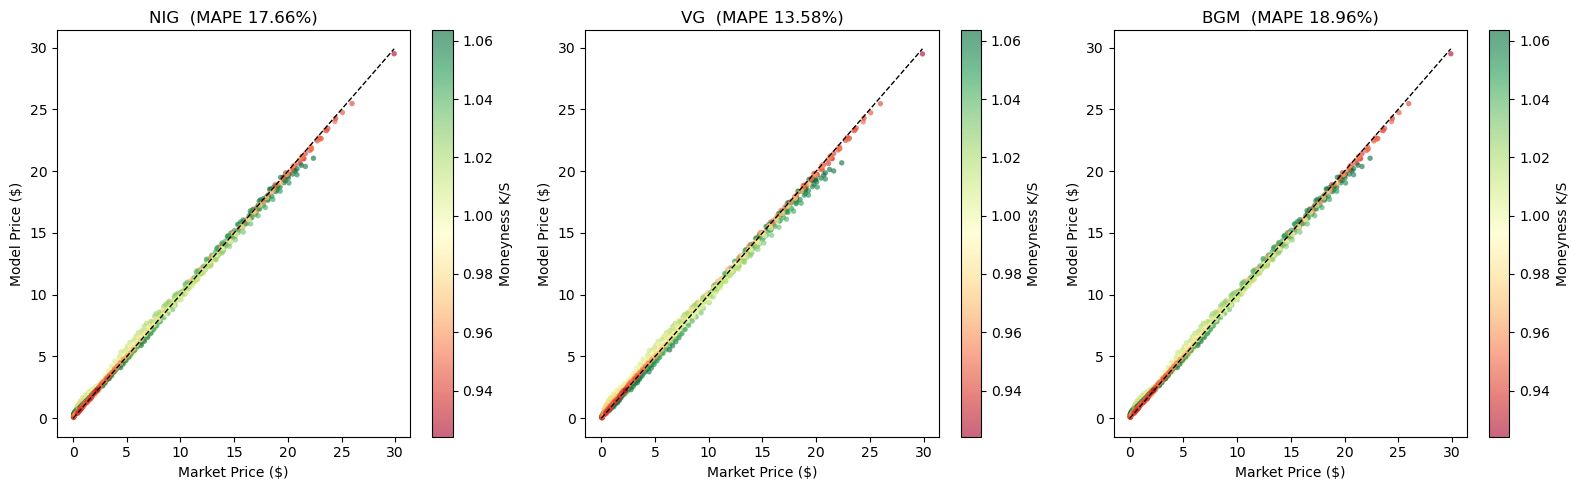

In [6]:
# ------------------------------------------------------------------
# Plots
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (label, ev) in zip(axes, [("NIG", nig_eval), ("VG", vg_eval), ("BGM", bgm_eval)]):
    # Compute model prices on-the-fly from the calibrated model
    model = ev["model"]
    model_calls = model.price_points(df["strike"].values, df["T"].values, GLD_SPOT, r_avg, q)
    model_prices = model_calls.copy()
    put_mask = df["option_type"].values == "put"
    if put_mask.any():
        model_prices[put_mask] -= (GLD_SPOT * np.exp(-q * df["T"].values[put_mask]) - df["strike"].values[put_mask] * np.exp(-r_avg * df["T"].values[put_mask]))
    
    rel_err = np.abs(model_prices - df["midPrice"].values) / (df["midPrice"].values + 1e-8) * 100
    mape = np.mean(rel_err)
    ax.hist(rel_err, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
    ax.axvline(mape, color="red", linestyle="--", label=f"MAPE = {mape:.2f}%")
    ax.set_xlabel("Relative Pricing Error (%)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{label} Error Distribution")
    ax.legend()
    ax.set_xlim(0, max(30, np.percentile(rel_err, 99)))
plt.tight_layout()
plt.savefig("gen2_levy_error_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
moneyness = df["strike"].values / GLD_SPOT
for ax, (label, ev) in zip(axes, [("NIG", nig_eval), ("VG", vg_eval), ("BGM", bgm_eval)]):
    # Compute model prices on-the-fly from the calibrated model
    model = ev["model"]
    model_calls = model.price_points(df["strike"].values, df["T"].values, GLD_SPOT, r_avg, q)
    model_prices = model_calls.copy()
    put_mask = df["option_type"].values == "put"
    if put_mask.any():
        model_prices[put_mask] -= (GLD_SPOT * np.exp(-q * df["T"].values[put_mask]) - df["strike"].values[put_mask] * np.exp(-r_avg * df["T"].values[put_mask]))
    
    rel_err = np.abs(model_prices - df["midPrice"].values) / (df["midPrice"].values + 1e-8) * 100
    mape = np.mean(rel_err)
    ax.scatter(df["midPrice"].values, model_prices, c=moneyness, cmap="RdYlGn", s=15, alpha=0.6, edgecolors="none")
    max_p = max(df["midPrice"].max(), model_prices.max())
    ax.plot([0, max_p], [0, max_p], "k--", lw=1)
    ax.set_xlabel("Market Price ($)")
    ax.set_ylabel("Model Price ($)")
    ax.set_title(f"{label}  (MAPE {mape:.2f}%)")
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    cbar.set_label("Moneyness K/S")
plt.tight_layout()
plt.savefig("gen2_levy_scatter_fit.png", dpi=300, bbox_inches="tight")
plt.show()
